# HOMO-LUMO gaps: Dataset and Physical stability surrogate
*A physics-grounded reward term for molecular generation*

## Abstract

A generative agent should avoid electronically unstable molecules. This notebook builds a reward term for that purpose. GFN2-xTB HOMO-LUMO gaps were computed for 49,505 drug-like ChEMBL molecules on an HPC cluster, then used to train fast surrogates. A gradient-boosted classifier separates unstable molecules (gap below 1.5 eV) from viable ones with ROC-AUC 0.957 under a scaffold split. Regressing the exact gap is harder (R² 0.64), and a graph neural network does not beat the fingerprint model. The classifier is adopted as the viability term used in the generation loop.

## Introduction

The reward that steers molecular generation should favour drug-like, active molecules and penalize chemically unreasonable ones. Electronic stability is one such constraint. A small HOMO-LUMO gap marks a molecule that is highly conjugated, easily oxidized or reduced, or otherwise reactive. GFN2-xTB gives a fast semi-empirical estimate of that gap. Even so, a single-point calculation on a 3D conformer is far too slow to run for every molecule inside a reinforcement-learning loop. The approach here is to compute the gap once on a large set of molecules, then train a surrogate that predicts it instantly from structure.

## Methods

**Dataset:** About 50,000 drug-like molecules were drawn from ChEMBL (molecular weight 150 to 600, no Lipinski violations). For each molecule, a 3D conformer was embedded and MMFF-optimized, and a single-point GFN2-xTB calculation gave the HOMO-LUMO gap. The workload ran on the Ecole Polytechnique SLURM cluster as a job array of 100 tasks with 4 cores each. The per-chunk results were concatenated, non-converged molecules dropped, and duplicate SMILES removed, leaving 49,505 gaps.

In [2]:
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

import pandas as pd, glob, os
import numpy as np, random 
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from collections import defaultdict
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from rdkit import Chem
import torch.nn as nn
from torch_geometric.nn import GraphConv, global_mean_pool
import joblib


plt.rcParams["figure.dpi"] = 80     
plt.rcParams["font.size"] = 9       
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8

/home/couret/miniconda3/envs/chemml/lib/python3.10/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [22]:
REPO = "/mnt/c/Users/coure/Projects/cheminformatics"
parts = glob.glob(f"{REPO}/xtb_results/*_out.csv")
print("cwd:", os.getcwd(), "| found files:", len(parts))
assert parts, "Aucun _out.csv — le scp a-t-il bien rempli xtb_results/ ?"

full = pd.concat([pd.read_csv(f) for f in parts], ignore_index=True)
print("raw lines:", len(full))
full["gap_eV"] = pd.to_numeric(full["gap_eV"], errors="coerce")   # vides -> NaN
full = full.dropna(subset=["gap_eV"]).drop_duplicates(subset="smiles")
full.to_csv(f"{REPO}/models/xtb_dataset.csv", index=False)
print("final dataset:", len(full), "molecules with a gap")

cwd: /mnt/c/Users/coure/AppData/Local/Programs/Microsoft VS Code | found files: 100
raw lines: 49999
final dataset: 49505 molecules with a gap


(49505, 3)
count    49505.000000
mean         2.618415
std          0.983176
min          0.001232
25%          2.136481
50%          2.653583
75%          3.115477
max         12.724292
Name: gap_eV, dtype: float64


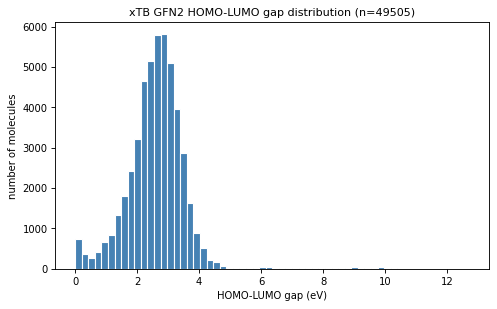

In [4]:
df = pd.read_csv(f"{REPO}/models/xtb_dataset.csv")
print(df.shape); print(df["gap_eV"].describe())

plt.figure(figsize=(7,4))
plt.hist(df["gap_eV"], bins=60, color="steelblue", edgecolor="white")
plt.xlabel("HOMO-LUMO gap (eV)"); plt.ylabel("number of molecules")
plt.title(f"xTB GFN2 HOMO-LUMO gap distribution (n={len(df)})"); plt.show()

In [5]:
print("Smallest gaps (highly conjugated or charged, reactive):")
print(df.nsmallest(5, "gap_eV")[["smiles", "gap_eV"]].to_string(index=False))
print("\nLargest gaps (saturated, stable):")
print(df.nlargest(5, "gap_eV")[["smiles", "gap_eV"]].to_string(index=False))

Smallest gaps (highly conjugated or charged, reactive):
                                                                              smiles   gap_eV
                              C[N+](C)(CCCN1C(=O)c2ccccc2C1=O)CCCN1C(=O)c2ccccc2C1=O 0.001232
CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCCN)C(=O)O)cc1.O=C(O)C(F)(F)F.O=C(O)C(F)(F)F 0.006167
                              C[N+](C)(CCCn1ccnc1[N+](=O)[O-])CCCn1ccnc1[N+](=O)[O-] 0.008356
                                CC[C@H](c1ccc(O)cc1)[C@@H](CC(=O)C[N+]#N)c1ccc(O)cc1 0.017058
                                                 C[N+](C)(C)CC#CCOC(=O)Nc1cccc(Cl)c1 0.017446

Largest gaps (saturated, stable):
         smiles    gap_eV
   CCCCCCCCCCCC 12.724292
   CCCCCCCCCCCO 12.221371
    CCCCCCCCCCO 12.188291
CCCCCCCCCCCCCCO 12.046145
 CCCCCCCCCCCCCO 12.026647


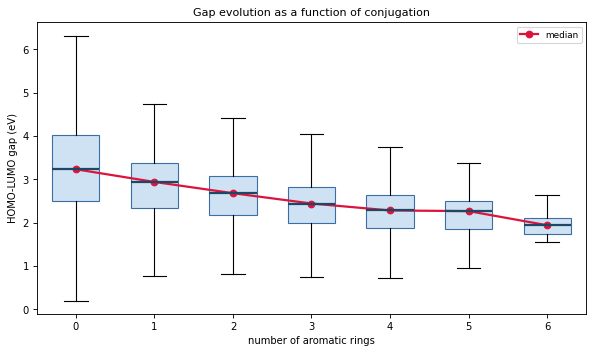

In [6]:
if "arom_rings" not in df.columns:
    df["arom_rings"] = df["smiles"].map(
        lambda s: rdMolDescriptors.CalcNumAromaticRings(m) if (m := Chem.MolFromSmiles(s)) else np.nan)

groups = sorted(df["arom_rings"].dropna().unique())
data = [df.loc[df["arom_rings"] == g, "gap_eV"] for g in groups]
medians = [d.median() for d in data]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bp = ax.boxplot(data, positions=groups, widths=0.6, showfliers=False, patch_artist=True)
for b in bp["boxes"]:   b.set(facecolor="#cfe2f3", edgecolor="#3b6ea5")
for m in bp["medians"]: m.set(color="#1b4965", linewidth=2)
ax.plot(groups, medians, "o-", color="crimson", lw=2, label="median")
ax.set_xlabel("number of aromatic rings"); ax.set_ylabel("HOMO-LUMO gap (eV)")
ax.set_title("Gap evolution as a function of conjugation")
ax.legend(); plt.tight_layout(); plt.show()

In [7]:
THR = 1.5                                   
df["unstable"] = (df["gap_eV"] < THR).astype(int)
print(f"threshold {THR} eV -> {df['unstable'].mean()*100:.1f}% unstable ({df['unstable'].sum()} molecules)")

threshold 1.5 eV -> 9.6% unstable (4731 molecules)


**Featurization and split:** Molecules were represented by ECFP4 fingerprints (Morgan, radius 2, 2048 bits). All models were evaluated under a Bemis-Murcko scaffold split, so that no scaffold appeared in both train and test.

**Models:** Two tasks were defined: a binary classification of unstable (gap below 1.5 eV) versus viable, and a regression of the exact gap. Both used a gradient-boosted tree model (XGBoost). A three-layer GraphConv graph neural network was trained on the molecular graph as an alternative representation for the regression, once on the raw target and once on a target standardized with train-only statistics.

## Results

The gap distribution is unimodal and centred near 4 to 5 eV. The gap falls steadily as the number of aromatic rings grows, as expected from conjugation. The smallest gaps belong to highly conjugated or charged species, the largest to saturated aliphatic chains.

At the 1.5 eV threshold, 9.6% of molecules are labelled unstable. The classifier reaches ROC-AUC 0.957 under the scaffold split. Regressing the exact gap is harder: XGBoost reaches R² 0.640 (RMSE 0.550 eV), the raw GNN R² 0.484, and the standardized GNN R² 0.542. XGBoost is best on every metric.

In [8]:
def ecfp(s):
    m = Chem.MolFromSmiles(s)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)) if m else None

def scaffold_split(smiles_list, test_size=0.2, seed=42):
    groups = defaultdict(list)
    for i, s in enumerate(smiles_list):
        m = Chem.MolFromSmiles(s)
        sc = MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else None
        groups[sc].append(i)
    sets = list(groups.values()); random.Random(seed).shuffle(sets)
    n_test, test, train = int(len(smiles_list) * test_size), [], []
    for g in sets:
        (test if len(test) < n_test else train).extend(g)
    return train, test

feats = [ecfp(s) for s in df["smiles"]]
ok = [i for i, f in enumerate(feats) if f is not None]
X = np.vstack([feats[i] for i in ok])
sub = df.iloc[ok].reset_index(drop=True)

THR = 1.5

y = (sub["gap_eV"] < THR).astype(int).values

tr, te = scaffold_split(sub["smiles"])

clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=0)
clf.fit(X[tr], y[tr])

proba = clf.predict_proba(X[te])[:, 1]        
auc = roc_auc_score(y[te], proba)
print("AUC (scaffold split):", round(auc, 3), "| unstable in test:", int(y[te].sum()), "/", len(te))

AUC (scaffold split): 0.957 | unstable in test: 928 / 9940


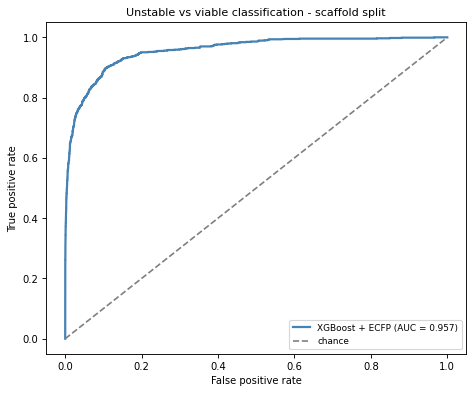

In [9]:
fpr, tpr, _ = roc_curve(y[te], proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"XGBoost + ECFP (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="chance")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Unstable vs viable classification - scaffold split")
plt.legend(); plt.tight_layout(); plt.show()

In [10]:
ygap = sub["gap_eV"].values
reg = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=0)
reg.fit(X[tr], ygap[tr])
pred = reg.predict(X[te])
r2 = r2_score(ygap[te], pred)
rmse = mean_squared_error(ygap[te], pred) ** 0.5
print(f"XGBoost + ECFP (gap regression) | R2 : {r2:.3f} | RMSE : {rmse:.3f} eV")

XGBoost + ECFP (gap regression) | R2 : 0.640 | RMSE : 0.550 eV


In [11]:
def mol_to_graph(smiles, y):
    m = Chem.MolFromSmiles(smiles)
    if m is None: return None
    x = [[a.GetAtomicNum(), a.GetDegree(), a.GetFormalCharge(),
          int(a.GetIsAromatic()), a.GetTotalNumHs()] for a in m.GetAtoms()]
    x = torch.tensor(x, dtype=torch.float)                      
    ei = []
    for b in m.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        ei += [[i, j], [j, i]]                                  
    edge_index = torch.tensor(ei, dtype=torch.long).t().contiguous() if ei else torch.empty((2, 0), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.float))

In [12]:
graphs = [mol_to_graph(s, g) for s, g in zip(sub["smiles"], ygap)]
train_ds = [graphs[i] for i in tr]
test_ds  = [graphs[i] for i in te]
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256)

In [13]:
class GapGNN(nn.Module):
    def __init__(self, in_dim=5, hidden=64):
        super().__init__()
        self.conv1 = GraphConv(in_dim, hidden)     
        self.conv2 = GraphConv(hidden, hidden)
        self.conv3 = GraphConv(hidden, hidden)
        self.head  = nn.Linear(hidden, 1)          
    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, ei).relu()
        x = self.conv2(x, ei).relu()
        x = self.conv3(x, ei).relu()
        x = global_mean_pool(x, batch)            
        return self.head(x).squeeze(-1)

In [14]:
model = GapGNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()

for epoch in range(30):
    model.train()
    for batch in train_loader:
        opt.zero_grad()                 
        pred = model(batch) 
        loss = lossf(pred, batch.y.view(-1)) 
        loss.backward()
        opt.step() 
    print("epoch", epoch, "loss", round(float(loss), 3))

/tmp/ipykernel_460359/4201864704.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  print("epoch", epoch, "loss", round(float(loss), 3))


epoch 0 loss 0.317
epoch 1 loss 0.396
epoch 2 loss 1.038
epoch 3 loss 0.245
epoch 4 loss 0.584
epoch 5 loss 0.394
epoch 6 loss 1.13
epoch 7 loss 0.455
epoch 8 loss 0.306
epoch 9 loss 0.395
epoch 10 loss 0.18
epoch 11 loss 0.404
epoch 12 loss 0.579
epoch 13 loss 0.351
epoch 14 loss 2.179
epoch 15 loss 0.552
epoch 16 loss 0.653
epoch 17 loss 0.369
epoch 18 loss 0.275
epoch 19 loss 3.288
epoch 20 loss 0.313
epoch 21 loss 0.547
epoch 22 loss 0.172
epoch 23 loss 0.841
epoch 24 loss 0.394
epoch 25 loss 0.271
epoch 26 loss 0.144
epoch 27 loss 0.225
epoch 28 loss 0.088
epoch 29 loss 0.158


In [15]:
model.eval(); preds, trues = [], []
with torch.no_grad():
    for batch in test_loader:
        preds.append(model(batch)); trues.append(batch.y.view(-1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()
gnn_r2, gnn_rmse = r2_score(trues, preds), mean_squared_error(trues, preds)**0.5
print(f"GNN (raw) | R2 : {gnn_r2:.3f} | RMSE : {gnn_rmse:.3f} eV")

GNN (raw) | R2 : 0.473 | RMSE : 0.665 eV


In [16]:
mu = float(np.mean([g.y.item() for g in train_ds]))   
sd = float(np.std([g.y.item() for g in train_ds]))

model = GapGNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()

for epoch in range(50):
    model.train()
    for batch in train_loader:
        opt.zero_grad()
        pred = model(batch)
        target = (batch.y.view(-1) - mu) / sd          
        loss = lossf(pred, target)
        loss.backward(); opt.step()
    if epoch % 5 == 0:
        print("epoch", epoch, "loss", round(loss.item(), 3))

epoch 0 loss 3.838
epoch 5 loss 0.392
epoch 10 loss 0.116
epoch 15 loss 0.693
epoch 20 loss 0.363
epoch 25 loss 0.331
epoch 30 loss 0.151
epoch 35 loss 0.211
epoch 40 loss 0.112
epoch 45 loss 0.145


In [17]:
model.eval(); preds, trues = [], []
with torch.no_grad():
    for batch in test_loader:
        preds.append(model(batch) * sd + mu)           
        trues.append(batch.y.view(-1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()
gnnn_r2, gnnn_rmse = r2_score(trues, preds), mean_squared_error(trues, preds)**0.5
print(f"GNN (normalised) | R² : {gnnn_r2:.3f} | RMSE : {gnnn_rmse:.3f} eV")

GNN (normalised) | R² : 0.597 | RMSE : 0.582 eV


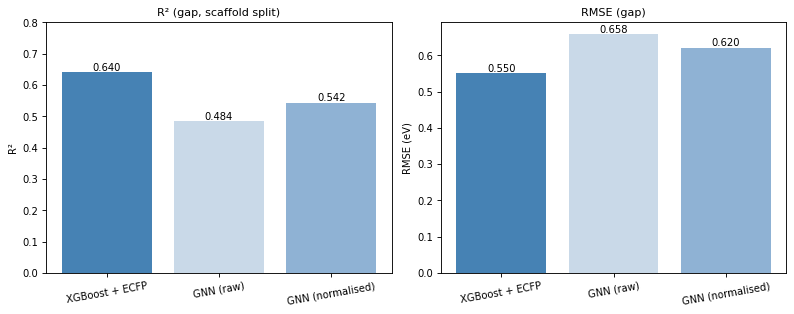

In [18]:
models = ["XGBoost + ECFP", "GNN (raw)", "GNN (normalised)"]
r2s    = [0.640, 0.484, 0.542]
rmses  = [0.550, 0.658, 0.620]
cols   = ["steelblue", "#c9d9e8", "#8fb2d4"]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(models, r2s, color=cols);   ax[0].set_ylabel("R²");        ax[0].set_ylim(0, 0.8); ax[0].set_title("R² (gap, scaffold split)")
ax[1].bar(models, rmses, color=cols); ax[1].set_ylabel("RMSE (eV)"); ax[1].set_title("RMSE (gap)")
for a, vals in [(ax[0], r2s), (ax[1], rmses)]:
    for i, v in enumerate(vals): a.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    a.tick_params(axis="x", labelrotation=10)
plt.tight_layout(); plt.show()

## Discussion

Classifying stable versus unstable is near-ceiling easy (AUC 0.957). ECFP fingerprints capture the 1.5 eV boundary well. Predicting the exact gap is harder, and the graph neural network does not beat XGBoost here. The raw GNN underfits, and standardizing the target lifts it but leaves it below XGBoost. The GNN was not tuned, with a fixed architecture and no early stopping or hyperparameter search. This is not evidence that graph networks are inferior on this target. It shows only that, at equal and non-optimized effort, the fixed-fingerprint model wins on the exact gap.

In [19]:
clf_full = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=0)
clf_full.fit(X, y)                                   
joblib.dump(clf_full, f"{REPO}/models/xtb_stability_clf.joblib")
print("stability classifier saved")

stability classifier saved


## Conclusion

The notebook delivers a distributed pipeline for computing a large quantum-chemical dataset and a fast, validated surrogate for electronic stability. The ECFP classifier is saved as the viability term of the generation reward. Its practical effect is limited, because drug-like molecules are almost always stable, so the term rarely binds during generation. Its value is a cheap safety net and a demonstration of an end-to-end pipeline from HPC quantum chemistry to a deployable model.